# Exercise: solving the nonlinear pendulum with Euler's method

The angular motion of an ideal pendulum is governed by

$$
\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin(\theta) = 0,
$$

where $\theta$ is the angular displacement in radians, $g$ is gravitational acceleration, and $L$ is the pendulum length. We solve this nonlinear equation numerically using the **explicit Euler method**.

## 1. Convert the second-order ODE into two first-order ODEs

Introduce the angular velocity

$$
\omega = \frac{d\theta}{dt}.
$$

The pendulum equation becomes

$$
\frac{d\theta}{dt}=\omega,
\qquad
\frac{d\omega}{dt}=-\frac{g}{L}\sin(\theta).
$$

For a time step $\Delta t$, explicit Euler gives

$$
\theta_{n+1}=\theta_n+\Delta t\,\omega_n,
$$

$$
\omega_{n+1}=\omega_n-\Delta t\,\frac{g}{L}\sin(\theta_n).
$$

> Both updates use the state at the start of the time step: $\theta_n$ and $\omega_n$.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Implement the solver

The function below stores time, angle, and angular velocity at every step. Initial angles supplied in degrees are converted to radians before calling the solver.

Explicit Euler is included because it is the method studied here. It is not energy-conserving, so its phase trajectory slowly spirals away from the exact closed orbit. Reducing $\Delta t$ reduces this numerical error.

In [7]:
def euler_pendulum(theta0, omega0, dt, t_end, g=9.81, length=1.0):
    """Solve the nonlinear pendulum equation using explicit Euler.

    Parameters
    ----------
    theta0 : float
        Initial angular displacement in radians.
    omega0 : float
        Initial angular velocity in radians per second.
    dt : float
        Time-step size in seconds. Must be positive.
    t_end : float
        Requested final time in seconds. Must be non-negative.
    g : float, optional
        Gravitational acceleration in m/s^2.
    length : float, optional
        Pendulum length in metres. Must be positive.

    Returns
    -------
    t, theta, omega : numpy.ndarray
        Arrays containing the time, angle, and angular velocity.

    Notes
    -----
    If t_end is not an exact multiple of dt, the last time step is
    shortened so that the returned solution ends exactly at t_end.
    """
    if dt <= 0:
        raise ValueError("dt must be positive")
    if t_end < 0:
        raise ValueError("t_end must be non-negative")
    if length <= 0:
        raise ValueError("length must be positive")

    # Construct time points, including a shortened final step if needed.
    n_full_steps = int(np.floor(t_end / dt))
    t = np.arange(n_full_steps + 1, dtype=float) * dt
    if t.size == 0 or not np.isclose(t[-1], t_end):
        t = np.append(t, t_end)

    theta = np.empty(t.size, dtype=float)
    omega = np.empty(t.size, dtype=float)
    theta[0] = theta0
    omega[0] = omega0

    for n in range(t.size - 1):
        step = t[n + 1] - t[n]

        # Evaluate acceleration from the state at time t[n].
        acceleration = -(g / length) * np.sin(theta[n])

        # Explicit Euler: both right-hand sides use the old state.
        theta[n + 1] = theta[n] + step * omega[n]
        omega[n + 1] = omega[n] + step * acceleration

    return t, theta, omega

## 3. Run an example

Release a one-metre pendulum from $20^\circ$ with zero initial angular velocity and calculate ten seconds of motion.

In [15]:
theta0 = np.deg2rad(20.0)  # degrees -> radians
omega0 = 0              # rad/s
dt = 0.01                 # s
t_end = 10.0              # s

t, theta, omega = euler_pendulum(
    theta0=theta0,
    omega0=omega0,
    dt=dt,
    t_end=t_end,
    g=9.81,
    length=1.0,
)

print(f"Number of time points: {len(t)}")
print(f"Final angle: {np.rad2deg(theta[-1]):.3f} degrees")
print(f"Final angular velocity: {omega[-1]:.3f} rad/s")

Number of time points: 1001
Final angle: 28.400 degrees
Final angular velocity: 0.835 rad/s


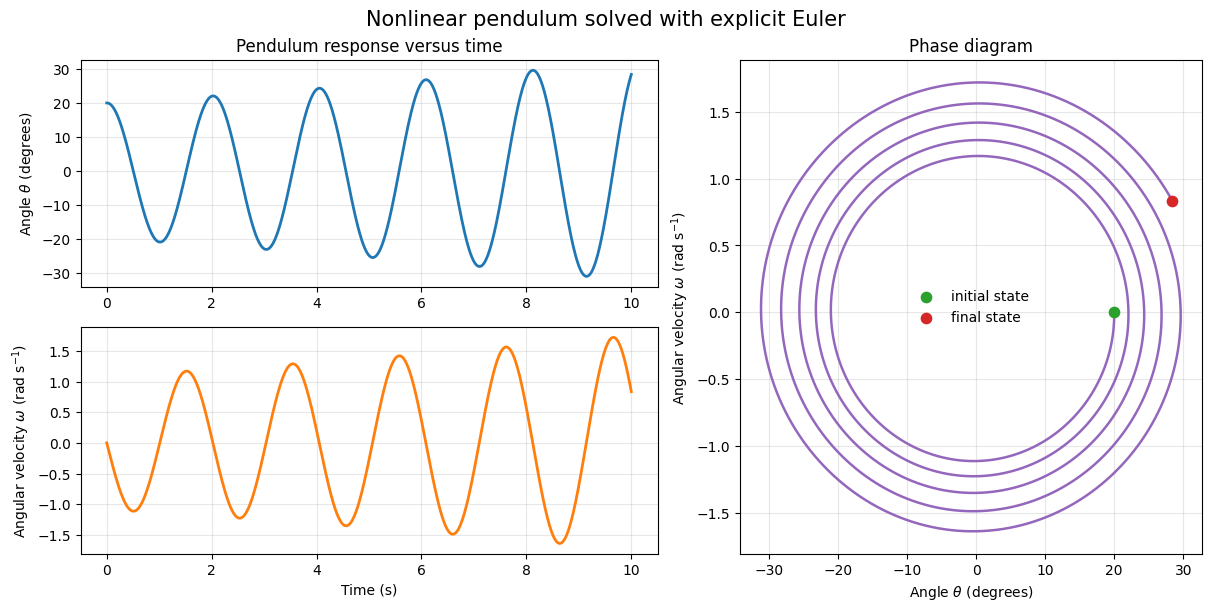

In [16]:
# Plot the state as a function of time and in phase space.
fig = plt.figure(figsize=(12, 6), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=(1.25, 1.0))

ax_theta = fig.add_subplot(grid[0, 0])
ax_omega = fig.add_subplot(grid[1, 0], sharex=ax_theta)
ax_phase = fig.add_subplot(grid[:, 1])

# Time histories
ax_theta.plot(t, np.rad2deg(theta), color="tab:blue", linewidth=2)
ax_theta.set_ylabel(r"Angle $\theta$ (degrees)")
ax_theta.set_title("Pendulum response versus time")
ax_theta.grid(alpha=0.3)

ax_omega.plot(t, omega, color="tab:orange", linewidth=2)
ax_omega.set_xlabel("Time (s)")
ax_omega.set_ylabel(r"Angular velocity $\omega$ (rad s$^{-1}$)")
ax_omega.grid(alpha=0.3)

# Phase diagram: angular velocity versus angular displacement
ax_phase.plot(np.rad2deg(theta), omega, color="tab:purple", linewidth=1.8)
ax_phase.scatter(
    np.rad2deg(theta[0]),
    omega[0],
    color="tab:green",
    s=55,
    zorder=3,
    label="initial state",
)
ax_phase.scatter(
    np.rad2deg(theta[-1]),
    omega[-1],
    color="tab:red",
    s=55,
    zorder=3,
    label="final state",
)
ax_phase.set_xlabel(r"Angle $\theta$ (degrees)")
ax_phase.set_ylabel(r"Angular velocity $\omega$ (rad s$^{-1}$)")
ax_phase.set_title("Phase diagram")
ax_phase.grid(alpha=0.3)
ax_phase.legend(frameon=False)

fig.suptitle("Nonlinear pendulum solved with explicit Euler", fontsize=15)
plt.show()

## 4. Check the numerical energy

For an ideal pendulum, the mechanical energy per unit mass is

$$
E=\frac{1}{2}L^2\omega^2+gL(1-\cos\theta).
$$

The exact solution conserves this energy. Explicit Euler generally increases it, so the energy plot and the outward spiral in the phase diagram reveal the same numerical error.

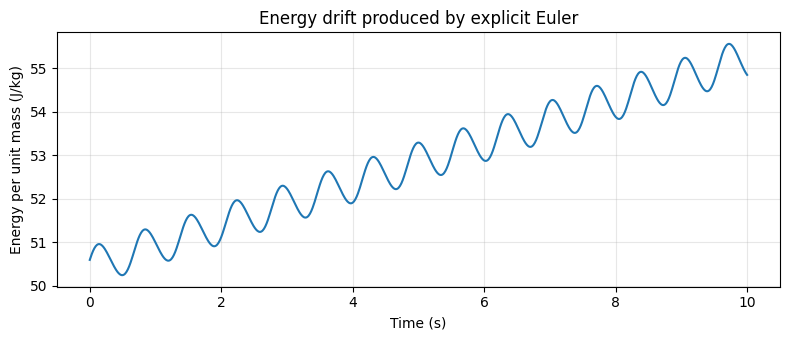

In [13]:
g = 9.81
length = 1.0
energy = 0.5 * length**2 * omega**2 + g * length * (1.0 - np.cos(theta))

plt.figure(figsize=(8, 3.5))
plt.plot(t, energy)
plt.xlabel("Time (s)")
plt.ylabel("Energy per unit mass (J/kg)")
plt.title("Energy drift produced by explicit Euler")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()